# PyTorch 图像预处理教学

以 `tech_gear.jpg` 为例，演示从原始图像到模型输入的完整处理流程。

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from IPython.display import display

## 1. 读取图像

`Image.open()` 返回 PIL 对象，`.convert("RGB")` 统一为三通道。注意 PIL 的 `.size` 返回 `(W, H)`，与 numpy 数组的 `(H, W, C)` 顺序相反。

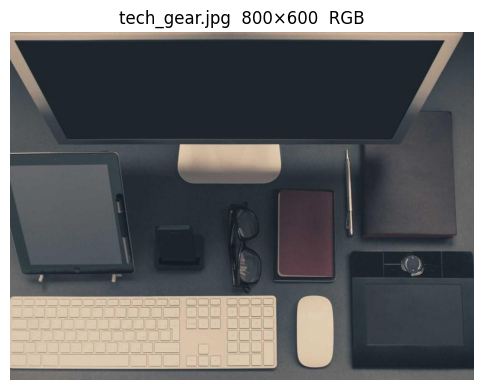

In [ ]:
IMG_PATH = Path("sample_data/tech_gear.jpg")
img_pil = Image.open(IMG_PATH).convert("RGB")

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(img_pil)
ax.set_title(f"{IMG_PATH.name}  {img_pil.size[0]}×{img_pil.size[1]}  {img_pil.mode}")
ax.axis("off")
plt.tight_layout()
plt.show()

## 2. PIL 与 OpenCV 的格式差异

| 库 | 通道顺序 | 数组形状 |
|---|---|---|
| PIL | RGB | H, W, C |
| OpenCV | **BGR** | H, W, C |
| PyTorch Tensor | RGB | **C, H, W** |

OpenCV 的 `cv2.imread()` 读入 BGR，显示或与 PIL 交互前必须转换：

```python
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
```

In [ ]:
pil_arr = np.array(img_pil)
cv2_bgr = cv2.imread(str(IMG_PATH))
cv2_rgb = cv2.cvtColor(cv2_bgr, cv2.COLOR_BGR2RGB)

print("PIL array :", pil_arr.shape, pil_arr.dtype, "— RGB")
print("cv2 imread:", cv2_bgr.shape, cv2_bgr.dtype, "— BGR")
print("转换后一致:", np.array_equal(pil_arr, cv2_rgb))

PIL array : (600, 800, 3) uint8 — RGB
cv2 imread: (600, 800, 3) uint8 — BGR
转换后一致: True


## 3. Resize 与插值

模型输入要求固定尺寸（如 224×224）。不同插值方式适用场景不同：

- `INTER_AREA`：缩小首选，抗锯齿
- `INTER_LINEAR`：通用默认
- `INTER_NEAREST`：分割 mask 专用，保持离散标签值

Jupyter 中除 matplotlib 外，`IPython.display.display()` 可直接内联显示 PIL 图像。

原始: (600, 800)  →  目标: (224, 224)


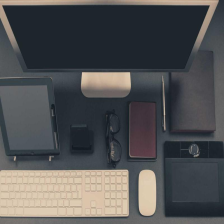

In [ ]:
rgb = np.array(img_pil)
target = (224, 224)

resized_area = cv2.resize(rgb, target, interpolation=cv2.INTER_AREA)
resized_linear = cv2.resize(rgb, target, interpolation=cv2.INTER_LINEAR)
resized_nearest = cv2.resize(rgb, target, interpolation=cv2.INTER_NEAREST)

print(f"原始: {rgb.shape[:2]}  →  目标: {resized_area.shape[:2]}")
display(Image.fromarray(resized_area))

## 4. 图像滤波

滤波的本质是用一个 **卷积核（kernel）** 在图像上滑动，将每个像素替换为其邻域的加权平均值。核的权重分布决定了滤波效果。

### 4.1 高斯滤波

核中每个位置的权重由二维高斯函数给出：

$$G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

- 核中心权重最大，向外递减，形成"钟形"分布
- `ksize` 控制核大小，`sigma` 控制衰减速度——sigma 越大，模糊越强
- 对所有像素一视同仁地平滑，**边缘和噪声一起被模糊**

```python
cv2.GaussianBlur(img, ksize=(7, 7), sigmaX=0)  # sigmaX=0 时由 ksize 自动推算
```

### 4.2 双边滤波

高斯滤波只考虑空间距离，双边滤波额外引入**像素值差异**作为第二个权重因子：

$$W(p, q) = \exp\left(-\frac{\|p - q\|^2}{2\sigma_s^2}\right) \cdot \exp\left(-\frac{|I(p) - I(q)|^2}{2\sigma_r^2}\right)$$

- 第一项（空间权重）：与高斯滤波相同，距离越远权重越小
- 第二项（值域权重）：像素值差异越大，权重越小。这使得**边缘两侧的像素互不影响**
- 效果：平坦区域正常平滑，边缘处保持锐利——即"保边去噪"
- 代价：无法用 FFT 加速，计算量比高斯滤波大得多

```python
cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
# d: 邻域直径  sigmaColor: 值域 sigma_r  sigmaSpace: 空间 sigma_s
```

### 对比总结

| | 高斯滤波 | 双边滤波 |
|---|---|---|
| 权重依据 | 仅空间距离 | 空间距离 + 像素差值 |
| 边缘表现 | 模糊 | 保持 |
| 计算速度 | 快（可分离、可 FFT） | 慢 |
| 典型用途 | 通用去噪、预处理 | 人像美颜、风格化 |

原图


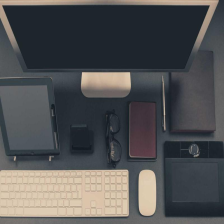

高斯滤波


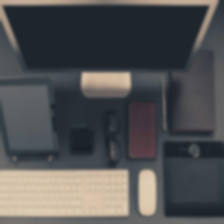

双边滤波


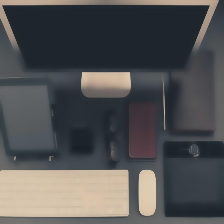

In [ ]:
resized = cv2.resize(rgb, (224, 224), interpolation=cv2.INTER_AREA)

gaussian = cv2.GaussianBlur(resized, (7, 7), sigmaX=0)
bilateral = cv2.bilateralFilter(resized, d=9, sigmaColor=75, sigmaSpace=75)

for name, arr in [("原图", resized), ("高斯滤波", gaussian), ("双边滤波", bilateral)]:
    print(name)
    display(Image.fromarray(arr))

## 5. numpy 数组 到 PyTorch Tensor

网络输入为 `float32` Tensor，形状 `C×H×W`，值域 `[0, 1]`。手动转换两步：除以 255 归一化，`permute` 调整维度顺序。`transforms.ToTensor()` 一步等效完成。

In [ ]:
tensor_manual = torch.from_numpy(resized).float() / 255.0
tensor_manual = tensor_manual.permute(2, 0, 1)

tensor_auto = transforms.ToTensor()(Image.fromarray(resized))

print("手动:", tensor_manual.shape, f"[{tensor_manual.min():.1f}, {tensor_manual.max():.1f}]")
print("auto:", tensor_auto.shape, f"[{tensor_auto.min():.1f}, {tensor_auto.max():.1f}]")
print("一致:", torch.allclose(tensor_manual, tensor_auto))

手动: torch.Size([3, 224, 224]) [0.1, 0.9]
auto: torch.Size([3, 224, 224]) [0.1, 0.9]
一致: True


## 6. torchvision.transforms 标准流水线

`Compose` 串联多个变换。ImageNet 预训练模型的标准化参数：

```python
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```

`Normalize` 后值域不再是 `[0, 1]`，显示前需反标准化：`x * std + mean`。

shape: torch.Size([3, 224, 224])
value range: [-1.81, 1.75]


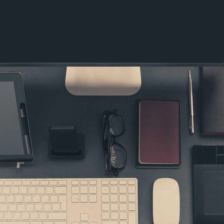

In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

tensor_norm = val_transform(img_pil)
print("shape:", tensor_norm.shape)
print(f"value range: [{tensor_norm.min():.2f}, {tensor_norm.max():.2f}]")

def denormalize(t, mean, std):
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

display(transforms.ToPILImage()(denormalize(tensor_norm, MEAN, STD)))

## 7. 数据增强

训练集用随机变换扩充样本多样性，提升泛化能力；验证集只做确定性变换。

`torchvision.utils.make_grid` 可将多个 Tensor 拼为网格图，适合批量预览。

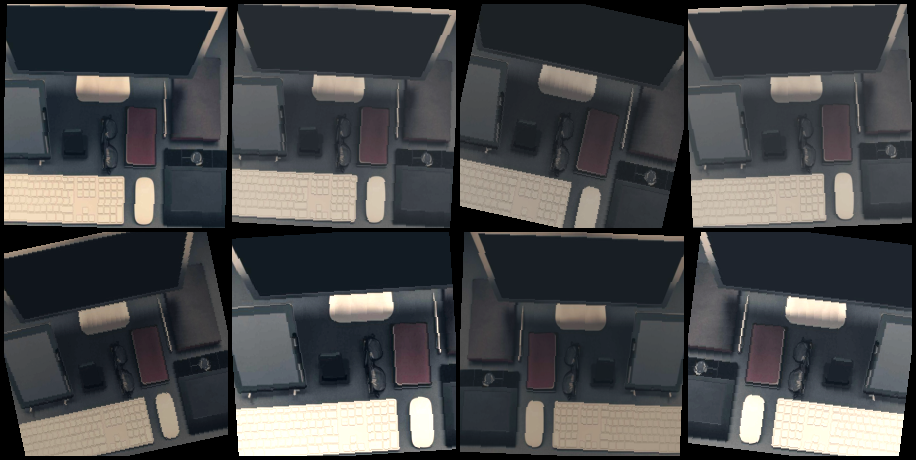

In [ ]:
aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

augmented = torch.stack([aug_transform(img_pil) for _ in range(8)])
grid = make_grid(augmented, nrow=4, padding=4)
display(transforms.ToPILImage()(grid))

## 8. Dataset 与 DataLoader

`Dataset` 定义单条数据的读取逻辑（`__getitem__`、`__len__`），`DataLoader` 负责分批、打乱和多进程加载。

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.paths = sorted(Path(image_dir).glob("*.jpg"))
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, idx

dataset = ImageDataset("sample_data", transform=val_transform)
loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)

images, labels = next(iter(loader))
print("batch:", images.shape, images.dtype)
print("labels:", labels.tolist())

batch: torch.Size([4, 3, 224, 224]) torch.float32
labels: [0, 1, 2, 3]


## 9. 遍历 Dataset 可视化

将 `sample_data/` 下 10 张图像经 `val_transform` 处理后，逐张从 Dataset 中读出，反标准化后用 matplotlib 展示。

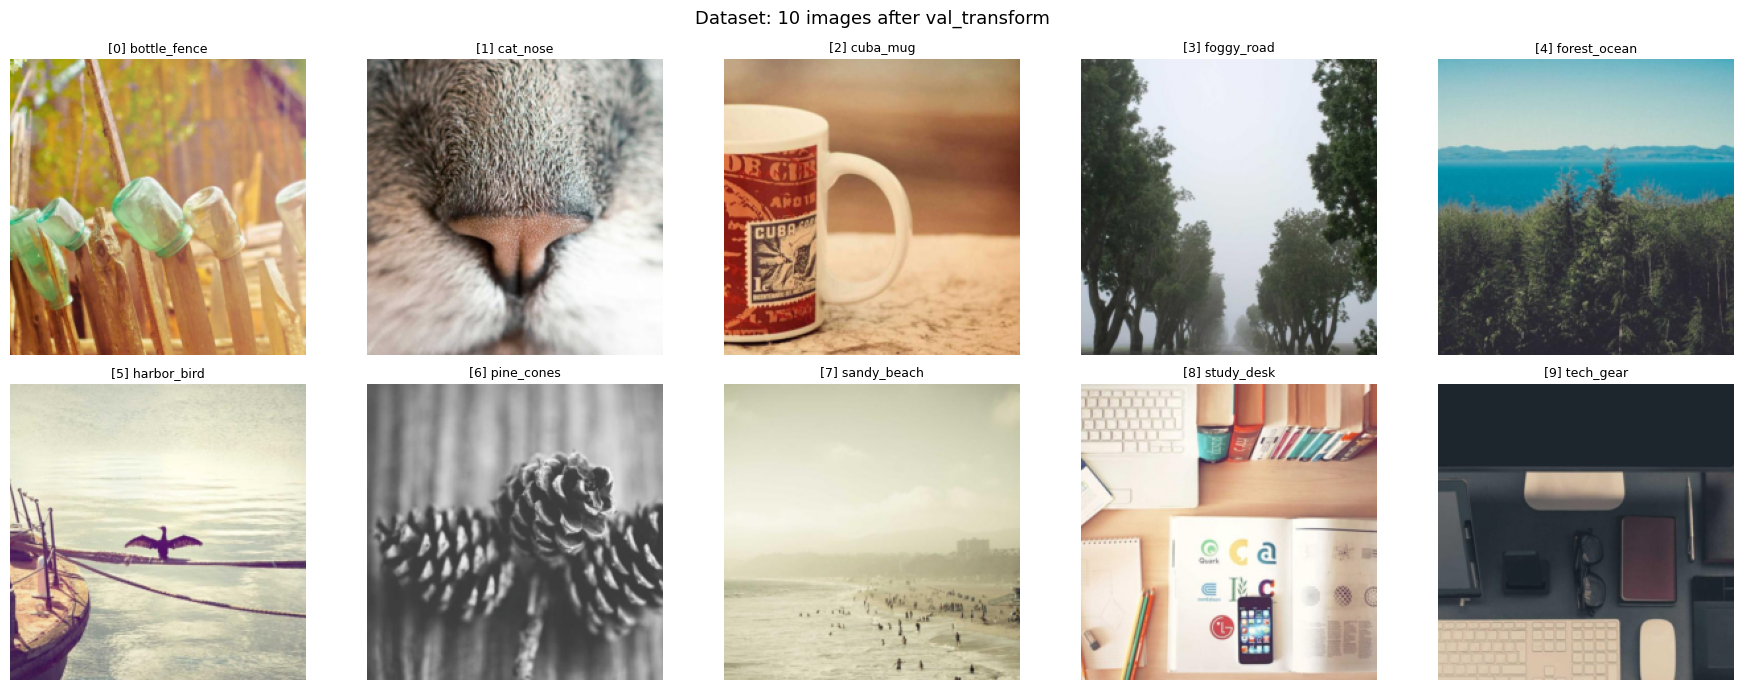

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for idx in range(len(dataset)):
    img_tensor, label = dataset[idx]
    img_show = denormalize(img_tensor, MEAN, STD).permute(1, 2, 0).numpy()
    filename = dataset.paths[idx].stem

    ax = axes[idx // 5, idx % 5]
    ax.imshow(img_show)
    ax.set_title(f"[{label}] {filename}", fontsize=9)
    ax.axis("off")

plt.suptitle("Dataset: 10 images after val_transform", fontsize=13)
plt.tight_layout()
plt.show()

## 10. 课堂练习

**任务**：`random_data/` 目录下混合存放了 `.jpg`、`.png`、`.txt`、`.py` 四种文件。请完成以下要求：

1. 扫描目录，**只加载 `.jpg` 和 `.png` 图像**（忽略其他文件类型）
2. 用 OpenCV 对每张图像施加**高斯滤波**去噪（ksize=5, sigmaX=0）
3. 将滤波后的图像转为 PIL Image，再经过下方给定的 `exercise_transform` 处理
4. 将上述逻辑封装为自定义 `Dataset`（`__getitem__` 返回 `(tensor, filename)`）
5. 用 `DataLoader` 以 `batch_size=4` 加载，取出第一个 batch
6. 对该 batch 反标准化后，用 matplotlib 展示 4 张图（1 行 4 列）

**提示**：
- `Path.glob("*")` 可以遍历所有文件，再按后缀过滤
- 高斯滤波在 RGB numpy 数组上操作，之后用 `Image.fromarray()` 转回 PIL
- DataLoader 默认要求每条数据的 tensor 形状一致，transform 中的 Resize 已保证这一点
- 反标准化函数 `denormalize` 可直接复用上面定义的版本
- 完成后运行下方**校验 cell**，通过则说明实现正确

**标准答案**见同目录下 `exercise_answer.py`，校验参考文件为 `exercise_reference.pt`。

共加载 16 张图像


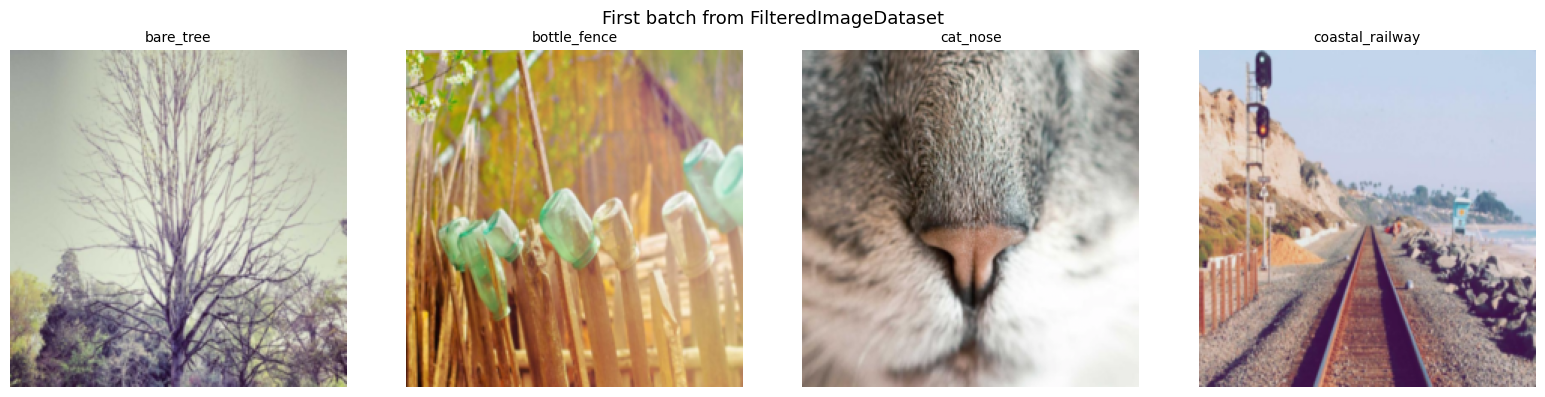

In [ ]:
EXERCISE_MEAN = [0.485, 0.456, 0.406]
EXERCISE_STD = [0.229, 0.224, 0.225]

exercise_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(EXERCISE_MEAN, EXERCISE_STD),
])

# ---- 请在下方完成代码 ----

class FilteredImageDataset(Dataset):
    """自定义 Dataset：只加载 jpg/png，读取时先做高斯滤波。"""

    def __init__(self, image_dir, transform=None):
        # TODO: 扫描 image_dir，筛选 .jpg 和 .png 文件路径
        pass

    def __len__(self):
        # TODO
        pass

    def __getitem__(self, idx):
        # TODO:
        # 1. 用 PIL 读取图像并 convert("RGB")
        # 2. 转为 numpy array，用 cv2.GaussianBlur 滤波 (ksize=(5,5), sigmaX=0)
        # 3. 转回 PIL Image
        # 4. 应用 self.transform
        # 5. 返回 (tensor, filename)  filename 不含后缀
        pass


# TODO: 创建 dataset 和 loader (batch_size=4, shuffle=False)
ex_dataset = ...
ex_loader = ...

# TODO: 取出第一个 batch (变量名保持 ex_batch, ex_names，校验 cell 会用到)
ex_batch, ex_names = None, None

# TODO: 反标准化后用 matplotlib 展示 (1 行 4 列)

In [16]:
# ---- 校验：运行此 cell 检查你的实现是否正确 ----
ref = torch.load("exercise_reference.pt", map_location="cpu", weights_only=True)

assert len(ex_dataset) == ref["total_images"], \
    f"图像数量不对: 你的 {len(ex_dataset)}, 期望 {ref['total_images']}"

assert list(ex_names) == ref["names"], \
    f"文件名或排序不对: 你的 {list(ex_names)}, 期望 {ref['names']}"

assert torch.equal(ex_batch, ref["tensors"]), \
    "Tensor 值不一致，请检查滤波参数和 transform 是否与要求一致"

print("ALL PASSED")
print(f"  Dataset 长度: {len(ex_dataset)}")
print(f"  Batch shape:  {ex_batch.shape}")
print(f"  文件名:       {ref['names']}")
print(f"  Checksum:     {ex_batch.sum().item():.2f}")

NameError: name 'ex_dataset' is not defined

## 总结

```
原始图像 → PIL 读取 → Resize → 滤波(可选) → ToTensor → Normalize → Dataset → DataLoader → [B,C,H,W] → 模型
```

| 操作 | 函数 |
|---|---|
| 读取 | `Image.open().convert("RGB")` |
| 格式转换 | `cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)` |
| 缩放 | `cv2.resize(img, size, interpolation=...)` |
| 滤波 | `cv2.GaussianBlur()` / `cv2.bilateralFilter()` |
| Tensor 化 | `transforms.ToTensor()` |
| 标准化 | `transforms.Normalize(mean, std)` |
| 增强 | `RandomResizedCrop` / `ColorJitter` / ... |
| 批量加载 | `DataLoader(dataset, batch_size=...)` |